# Test 0

In [ ]:
import main2DIR as dd_ir
import numpy as np

# # testing template function for w_mn terms for the whole 2d spectrum tensor
w_all = {'0': 1., '1': 5., '00': 2., '01': 6., '11': 10.}
Gamma = 10 ** (-0.3)
w1, w2 = np.arange(1, 13, 2), np.arange(1, 13, 2)
w1grid, w2grid = np.meshgrid(w1, w2)
fundamentals = {'0': 1., '1': 5.}

test2d = dd_ir.SpectrumEVV(w1, w2, fundamentals, Gamma, False, molfile='MOLECULE.INP', rspfile='rsp_tensor')

electrical_terms = [('a+b,a', 'zero,a'), ('b,a', 'zero,a')]

electric_avrg = [[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_QQ', ('a', 'b',))],
                 [('mu_Q', ('a',)), ('alpha_QQ', ('a', 'b',)), ('mu_Q', ('b',))]]

mechanical_terms = [[('a+b,a', 'zero,a'), ('a+b+c,zero', 'c,a+b')], 
                    [('c,a', 'zero,a'), ('a+b,c', 'b+c,a')],
                    [('a+b,a', 'zero,a'), ('a,a+b', 'b,zero')], 
                    [('b,a', 'zero,a'), ('b,a+b', 'a,zero')],
                    [('b,a', 'zero,a'), ('a,a+b', 'b,zero')], 
                    [('b,a', 'zero,a'), ('b,a+b', 'a,zero')]]

mechanical_avrg = [[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('c',)), 'abc'],
                   [('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('c',)), 'abc'],
                   [('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('a',)), 'bcc'],
                   [('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('b',)), 'acc'],
                   [('mu_Q', ('a',)), ('alpha_Q', ('a',)), ('mu_Q', ('b',)), 'bcc'],
                   [('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('b',)), 'acc']]

test2d.addTerms(electrical_terms, mechanical_terms, electric_avrg, mechanical_avrg)
test2d.combofuns

test2d.gamma_mn(0, 0)

coords_ab = dd_ir.get_abc(2, len(test2d.fundamentals))
test2d.plot2D(coords_ab=coords_ab, coords_abc=[], w1mw2=False)

# Test 1 - CH3CN

In [ ]:
import main2DIR as dd_ir
import numpy as np

%matplotlib widget
from ipywidgets import *

# w1, w2 = np.arange(0., 120, 1.), np.arange(0, 120, 1.)
w1, w2 = np.arange(1200., 3420, 15), np.arange(2300., 5320, 15)

funds = {'0':20, '1':30
                , '2':50
               }
# funds = dict(zip(['0', '1', '2'], [1775.31613305, 4176.50018401, 4267.11828147]))
funds = dict(zip(['0', '1', '2', '3', '4', '5'], [1354.33983658, 1362.02594387, 1618.89707406, 1860.47711028, 2981.21568204, 3057.08908481]))

h = dd_ir.SpectrumEVV(w1, w2, funds, Gamma=10**(-0.003), avrg_ones=False, molfile='./ch3cn/MOLECULE.INP', rspfile='./ch3cn/rsp_tensor')
# h = dd_ir.SpectrumEVV(w1, w2, funds, Gamma=10**(-0.003), avrg_ones=False, molfile='MOLECULE.INP', rspfile='rsp_tensor')

electrical_terms = [('a+b,a', 'zero,a')
                   # ('b,a', 'zero,a')
                   ]

electric_avrg = [[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_QQ', ('a', 'b',))]
                  #[('mu_Q', ('a',)), ('alpha_QQ', ('a', 'b',)), ('mu_Q', ('b',))]
                ]

mechanical_terms = [[('a+b,a', 'zero,a'), ('a+b+c,zero', 'c,a+b')], 
                     #[('c,a', 'zero,a'), ('a+b,c', 'b+c,a')],
                     #[('a+b,a', 'zero,a'), ('a,a+b', 'b,zero')], 
                     #[('b,a', 'zero,a'), ('b,a+b', 'a,zero')],
                     #[('b,a', 'zero,a'), ('a,a+b', 'b,zero')], 
                     #[('b,a', 'zero,a'), ('b,a+b', 'a,zero')]
                   ]

mechanical_avrg = [[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('c',)), 'abc'],
                    #[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('c',))],
                    #[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('a',))],
                    #[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('b',))],
                    #[('mu_Q', ('a',)), ('alpha_Q', ('a',)), ('mu_Q', ('b',))],
                    #[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('b',))]
                  ]

# electrical_terms, electric_avrg = [], []
# mechanical_terms, mechanical_avrg = [], []

h.addTerms(electrical_terms, mechanical_terms, electric_avrg, mechanical_avrg)

coords_ab = dd_ir.get_abc(2, len(h.fundamentals))
coords_abc = dd_ir.get_abc(3, len(h.fundamentals))

# print(coords_abc)

# h.plot2D(coords_ab=[], coords_abc=coords_abc, w1mw2=False)
r = h.plot2D(coords_ab=coords_ab, coords_abc=coords_abc, w1mw2=False)
h.plot2D_surface(coords_ab=coords_ab, coords_abc=coords_abc, w1mw2=False)

print(r)
# h.plot2D_surface(coords_ab=[], coords_abc=coords_abc, w1mw2=False)

# for i in coords_ab:
#     print(i, h.fundamentals[str(i[0])], h.fundamentals[str(i[1])])
#     h.plot2D(coords_ab=[], coords_abc=[i], w1mw2=False)


In [ ]:
print(coords_abc[0])

# Test 2 - H2O and CH3CN

In [ ]:
import main2DIR as dd_ir
import numpy as np

%matplotlib widget
from ipywidgets import *

# w1, w2 = np.arange(0., 120, 1.), np.arange(0, 120, 1.)
w1, w2 = np.arange(1200., 4420, 15), np.arange(2300., 8320, 15)

funds = {'0':20, '1':30
                , '2':50
               }
funds = dict(zip(['0', '1', '2'], [1775.31613305, 4176.50018401, 4267.11828147]))
# funds = dict(zip(['0', '1', '2', '3', '4', '5'], [1354.33983658, 1362.02594387, 1618.89707406, 1860.47711028, 2981.21568204, 3057.08908481]))

# h = dd_ir.SpectrumEVV(w1, w2, funds, Gamma=10**(-0.003), avrg_ones=False, molfile='./ch3cn/MOLECULE.INP', rspfile='./ch3cn/rsp_tensor')
h = dd_ir.SpectrumEVV(w1, w2, funds, Gamma=10**(-0.003), avrg_ones=False, molfile='MOLECULE.INP', rspfile='rsp_tensor')

electrical_terms = [('a+b,a', 'zero,a')
                   # ('b,a', 'zero,a')
                   ]

electric_avrg = [[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_QQ', ('a', 'b',))]
                  #[('mu_Q', ('a',)), ('alpha_QQ', ('a', 'b',)), ('mu_Q', ('b',))]
                ]

mechanical_terms = [[('a+b,a', 'zero,a'), ('a+b+c,zero', 'c,a+b')], 
                     #[('c,a', 'zero,a'), ('a+b,c', 'b+c,a')],
                     #[('a+b,a', 'zero,a'), ('a,a+b', 'b,zero')], 
                     #[('b,a', 'zero,a'), ('b,a+b', 'a,zero')],
                     #[('b,a', 'zero,a'), ('a,a+b', 'b,zero')], 
                     #[('b,a', 'zero,a'), ('b,a+b', 'a,zero')]
                   ]

mechanical_avrg = [[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('c',)), 'abc'],
                    #[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('c',))],
                    #[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('a',))],
                    #[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('b',))],
                    #[('mu_Q', ('a',)), ('alpha_Q', ('a',)), ('mu_Q', ('b',))],
                    #[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('b',))]
                  ]

# electrical_terms, electric_avrg = [], []
# mechanical_terms, mechanical_avrg = [], []

h.addTerms(electrical_terms, mechanical_terms, electric_avrg, mechanical_avrg)

coords_ab = dd_ir.get_abc(2, len(h.fundamentals))
coords_abc = dd_ir.get_abc(3, len(h.fundamentals))

# print(coords_abc)

# h.plot2D(coords_ab=[], coords_abc=coords_abc, w1mw2=False)
r = h.plot2D(coords_ab=coords_ab, coords_abc=coords_abc, w1mw2=False)
h.plot2D_surface(coords_ab=coords_ab, coords_abc=coords_abc, w1mw2=False)

print(r)
# h.plot2D_surface(coords_ab=[], coords_abc=coords_abc, w1mw2=False)

# for i in coords_ab:
#     print(i, h.fundamentals[str(i[0])], h.fundamentals[str(i[1])])
#     h.plot2D(coords_ab=[], coords_abc=[i], w1mw2=False)


# All new tests

## Symbolic notation for terms

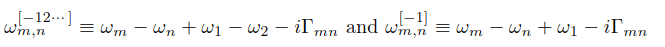

$\omega_1 = \omega_n - \omega_m$


$\omega_2 = \omega_m - \omega_n + \omega_1$

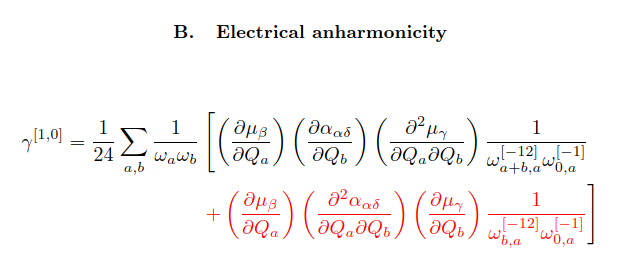

In [ ]:
def get_signals(self, term, mech=False):
    if not mech:
        self.all_states['zero'] = 0.
        
        abstuplesss = self.get_abc(2, len(h.fundamentals))
        for abstuple in abstuplesss:
            letters = ['a', 'b', 'c', 'zero'] if len(abctuple) == 3 else ['a', 'b', 'zero']
            dictabc = dict(zip(letters, abctuple + tuple(['zero'])))

            m1n1m2n2 = [i.split(',') for i in subscripts]
            wm1 = ''.join(sorted([str(dictabc[i]) for i in m1n1m2n2[0][0].split('+')]))
            wn1 = ''.join(sorted([str(dictabc[i]) for i in m1n1m2n2[0][1].split('+')]))
            wm2 = ''.join(sorted([str(dictabc[i]) for i in m1n1m2n2[1][0].split('+')]))
            wn2 = ''.join(sorted([str(dictabc[i]) for i in m1n1m2n2[1][1].split('+')]))
        

In [1]:
# Terms in expressions
electrical_terms = [('a+b,a', 'zero,a')
                   ,('b,a', 'zero,a')
                   ]

electric_avrg = [[ ('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_QQ', ('a', 'b',)) ]
                  ,[ ('mu_Q', ('a',)), ('alpha_QQ', ('a', 'b',)), ('mu_Q', ('b',)) ]
                ]

mechanical_terms = [ [('a+b,a', 'zero,a'), ('a+b+c,zero', 'c,a+b')]
                     # ,[('c,a', 'zero,a'), ('a+b,c', 'b+c,a')]
                     # ,[('a+b,a', 'zero,a'), ('a,a+b', 'b,zero')]
#                      #,[('b,a', 'zero,a'), ('b,a+b', 'a,zero')]
#                      #,[('b,a', 'zero,a'), ('a,a+b', 'b,zero')]
#                      #,[('b,a', 'zero,a'), ('b,a+b', 'a,zero')]
                   ]

mechanical_avrg = [[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('c',)), 'abc']
                    # ,[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('c',))]
                    # ,[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('a',))]
#                     #,[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('b',))]
#                     #,[('mu_Q', ('a',)), ('alpha_Q', ('a',)), ('mu_Q', ('b',))]
#                     #,[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('b',))]
                  ]

# # electrical_terms, electric_avrg = [], []
mechanical_terms, mechanical_avrg = [], []

## Test 0

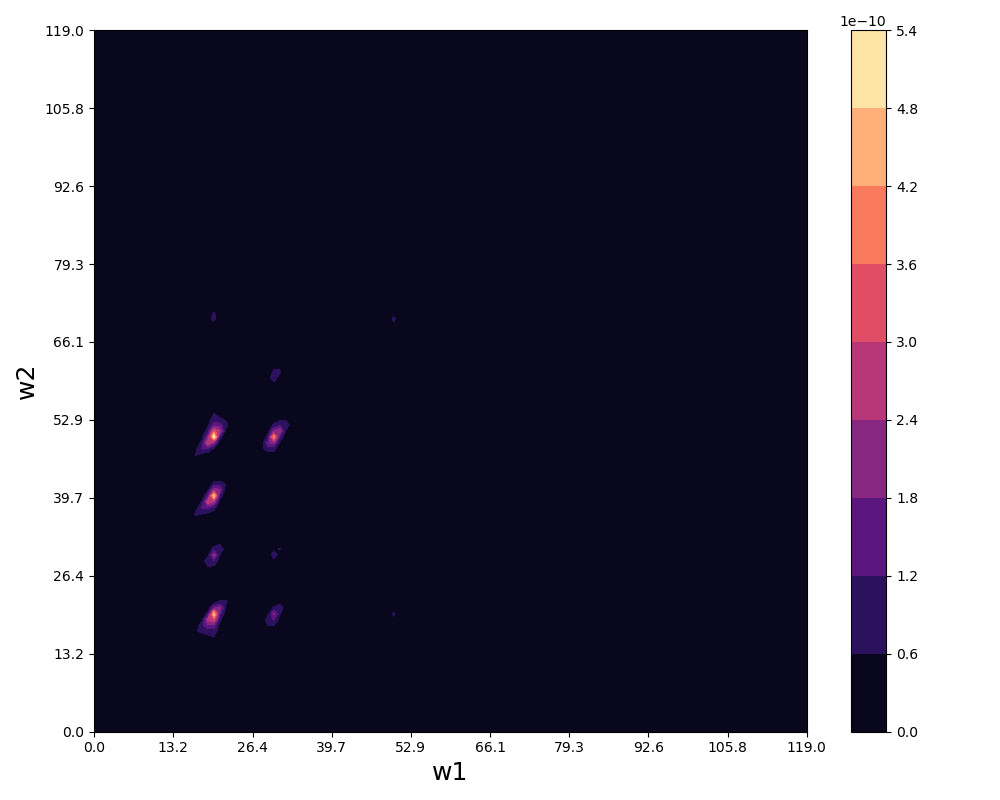

In [5]:
import main2DIR as dd_ir
import numpy as np

%matplotlib widget
from ipywidgets import *

test1 = True
###    Test 1
if test1:
    # set up frequencies for x and y axes
    w1, w2 = np.arange(0., 120, 1.), np.arange(0, 120, 1.)
    funds = {'0': 20, '1': 30
                    , '2': 50
                  }

    # create class instance
    h = dd_ir.SpectrumEVV(w1, w2, funds, Gamma=10**(-0.003), avrg_ones=True)

    # get derivatives - mu_Q, mu QQ, alpha_Q, alphaQQ, F_abc
    derivData = h.getDerivs()
    
    # print(derivData)

    # add mechanical and electrical anharmonicities terms and oriantational averages (symbolic setup)
    h.addTerms(electrical_terms, mechanical_terms, electric_avrg, mechanical_avrg)

    # pairs of normal mode indices
    Q_ab = dd_ir.get_abc(2, len(h.fundamentals))
    Q_abc = dd_ir.get_abc(3, len(h.fundamentals))
    
    # plot (and save plot) 2D spectrum
    h.plot2D(Q_ab, Q_abc, figname='test1', w1mw2=False, surface=False)

## Test 1: H2O

In [ ]:
waterBool = True
###    Test 2 (H2O)
if waterBool:
    # set up frequencies for x and y axes
    w1, w2 = np.arange(1200., 3420, 15), np.arange(2300., 5320, 15)
    funds = dict(zip(['0', '1', '2'], [1775.31613305, 4176.50018401, 4267.11828147]))

    # create class instance
    h = dd_ir.SpectrumEVV(w1, w2, funds, Gamma=10**(-0.003), avrg_ones=False)

    # get derivatives - mu_Q, mu QQ, alpha_Q, alphaQQ, F_abc
    derivData = h.getDerivs(molfile='MOLECULE.INP', rspfile='rsp_tensor')

    # add mechanical and electrical anharmonicities terms and oriantational averages (symbolic setup)
    h.addTerms(electrical_terms, mechanical_terms, electric_avrg, mechanical_avrg)

    # pairs of normal mode indices
    Q_ab = dd_ir.get_abc(2, len(h.fundamentals))
    Q_abc = dd_ir.get_abc(3, len(h.fundamentals))

    # plot (and save plot) 2D spectrum
    h.plot2D(Q_ab, Q_abc, figname='h2o', w1mw2=False, surface=False)

## Test 2: CH3CN

In [ ]:
acetonitrileBool = True
###    Test 2 (CH3CN)
if acetonitrileBool:
    
    # set up frequencies for x and y axes
    w1, w2 = np.arange(1200., 3420, 15), np.arange(2300., 5320, 15)
    funds = dict(zip(['0', '1', '2', '3', '4', '5'],
                     [1354.33983658, 1362.02594387, 1618.89707406, 1860.47711028, 2981.21568204, 3057.08908481]))
    
    # create class instance
    h = dd_ir.SpectrumEVV(w1, w2, funds, Gamma=10**(-0.003), avrg_ones=False)
    
    # get derivatives - mu_Q, mu QQ, alpha_Q, alphaQQ, F_abc from the rsp_tensor file
    # includes basis transformation
    dd = h.getDerivs(molfile='./ch3cn/MOLECULE.INP', rspfile='./ch3cn/rsp_tensor')
    
    # add mechanical and electrical anharmonicities terms and oriantational averages (symbolic setup)
    h.addTerms(electrical_terms, mechanical_terms, electric_avrg, mechanical_avrg)

    # pairs of normal mode indices
    Q_ab = dd_ir.get_abc(2, len(h.fundamentals))
    Q_abc = dd_ir.get_abc(3, len(h.fundamentals))

    # plot (and save plot) 2D spectrum
    h.plot2D(Q_ab, Q_abc, figname='ch3cn', w1mw2=False, surface=False)

In [ ]:

#
# electrical_terms = [('a+b,a', 'zero,a')
#                    # ('b,a', 'zero,a')
#                    ]
#
# electric_avrg = [[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_QQ', ('a', 'b',))]
#                   #[('mu_Q', ('a',)), ('alpha_QQ', ('a', 'b',)), ('mu_Q', ('b',))]
#                 ]
#
# mechanical_terms = [[('a+b,a', 'zero,a'), ('a+b+c,zero', 'c,a+b')],
#                      #[('c,a', 'zero,a'), ('a+b,c', 'b+c,a')],
#                      #[('a+b,a', 'zero,a'), ('a,a+b', 'b,zero')],
#                      #[('b,a', 'zero,a'), ('b,a+b', 'a,zero')],
#                      #[('b,a', 'zero,a'), ('a,a+b', 'b,zero')],
#                      #[('b,a', 'zero,a'), ('b,a+b', 'a,zero')]
#                    ]
#
# mechanical_avrg = [[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('c',)), 'abc'],
#                     #[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('c',))],
#                     #[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('a',))],
#                     #[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('b',))],
#                     #[('mu_Q', ('a',)), ('alpha_Q', ('a',)), ('mu_Q', ('b',))],
#                     #[('mu_Q', ('a',)), ('alpha_Q', ('b',)), ('mu_Q', ('b',))]
#                   ]
#
# # electrical_terms, electric_avrg = [], []
# # mechanical_terms, mechanical_avrg = [], []
#
# h.addTerms(electrical_terms, mechanical_terms, electric_avrg, mechanical_avrg)
#
# coords_ab = dd_ir.get_abc(2, len(h.fundamentals))
# coords_abc = dd_ir.get_abc(3, len(h.fundamentals))
#
# # print(coords_abc)
#
# # h.plot2D(coords_ab=[], coords_abc=coords_abc, w1mw2=False)
# r = h.plot2D(coords_ab=coords_ab, coords_abc=coords_abc, w1mw2=False)
# h.plot2D_surface(coords_ab=coords_ab, coords_abc=coords_abc, w1mw2=False)
#
# print(r)

# h.plot2D_surface(coords_ab=[], coords_abc=coords_abc, w1mw2=False)

# for i in coords_ab:
#     print(i, h.fundamentals[str(i[0])], h.fundamentals[str(i[1])])
#     h.plot2D(coords_ab=[], coords_abc=[i], w1mw2=False)
